# Health Data Analysis Project

**Project goal:**
This dataset contains health-related information for 4157 individuals, including Age, BMI (Body Mass Index), Blood Pressure (Systolic and Diastolic), Cholesterol levels (Total, HDL, LDL), Triglycerides, Smoking Status, and Physical Activity Level.

**Project steps:**
1. **Data Exploration** - understand the shape of the data, the columns, and their data types.
2. **Data Visualization** - plot the data to understand distributions and relationships between variables.
3. **Data Preprocessing** - clean the data (handle missing values and outliers), then prepare it for Machine Learning through Encoding and Scaling.

---

## 1. Import Libraries

We import the core libraries needed for this project:
- **numpy**: for numerical operations and array handling.
- **pandas**: to read the data and work with it as a DataFrame.
- **matplotlib.pyplot**: to plot charts (visualization).
- **seaborn**: a plotting library built on top of matplotlib, offering nicer and more convenient statistical visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Here we read the `health_data.csv` file into a DataFrame called `df` so we can work with it.

In [8]:
df=pd.read_csv("health_data.csv")

## Column Descriptions

Before exploring the data, here is a description of what each column represents:

| Column Name | Description |
|---|---|
| `Unnamed: 0` | A leftover row index column created when the CSV file was saved. Not a real feature, dropped during preprocessing. |
| `Age` | The person's age, in years. |
| `BMI` | Body Mass Index, a measure of body fat based on weight and height (weight in kg divided by height in meters squared). |
| `Systolic_BP` | Systolic blood pressure, the pressure in the arteries when the heart beats (the "top" number in a blood pressure reading). |
| `Diastolic_BP` | Diastolic blood pressure, the pressure in the arteries when the heart rests between beats (the "bottom" number in a blood pressure reading). |
| `Total_Cholesterol` | The total amount of cholesterol in the blood, combining HDL, LDL, and other lipid components. |
| `HDL_Cholesterol` | High-Density Lipoprotein cholesterol, often called "good" cholesterol, which helps remove other forms of cholesterol from the bloodstream. |
| `LDL_Cholesterol` | Low-Density Lipoprotein cholesterol, often called "bad" cholesterol, which can build up in artery walls when levels are high. |
| `Triglycerides` | A type of fat (lipid) found in the blood, used for energy; high levels are linked to heart disease risk. |
| `Smoking_Status` | Whether the person is a smoker or non-smoker. |
| `Physical_Activity_Level` | The person's level of physical activity, categorized as low, moderate, or high. |

## 3. Data Exploration

Before any analysis or cleaning, we need to understand the data we have: how many rows and columns, what the data looks like, its data types, and whether there are any missing values.

### Shape of the Data
`df.shape` returns the number of rows and columns in the DataFrame.

In [9]:
df.shape

(4157, 11)

**Interpretation:** The dataset has **4157 rows** and **11 columns**, meaning we have 4157 individuals, each with 11 recorded features.

### First 5 Rows (Head)
`df.head()` displays the first 5 rows of the data so we get a quick look at the columns and their values.

In [11]:
df.head()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,0.0,69.0,20.716059,107.148438,58.251503,168.918511,38.417674,183.835062,243.341527,non-smoker,moderate
1,1.0,32.0,26.720231,102.948326,86.641598,203.912014,39.611571,209.084595,266.375425,smoker,high
2,2.0,89.0,25.971636,116.327033,90.282522,213.564817,39.406223,245.884831,256.974525,non-smoker,moderate
3,3.0,78.0,29.580788,104.273800,85.582392,204.301914,33.026881,207.493647,257.717821,non-smoker,moderate
4,4.0,38.0,28.353130,104.052584,81.326270,195.767143,34.558842,213.826737,246.513400,non-smoker,moderate


**Interpretation:** There is a column called `Unnamed: 0`, which is most likely a leftover index column from saving the file, and it will be removed later during cleaning. The rest of the columns are numerical, except for `Smoking_Status` and `Physical_Activity_Level`, which are categorical (text).

### Last 5 Rows (Tail)
`df.tail()` displays the last 5 rows of the data. We use it to confirm the data is consistent all the way to the end, with no issues such as empty or corrupted rows.

In [12]:
df.tail()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
4152,4152.0,78.0,32.858594,120.138588,86.568177,199.981461,38.245568,220.002560,284.160583,non-smoker,low
4153,4153.0,33.0,32.103409,111.747372,87.346492,206.345116,43.579222,223.586710,248.753407,non-smoker,moderate
4154,4154.0,19.0,27.619843,125.698572,90.890419,204.276241,36.233885,232.877727,232.025423,non-smoker,moderate
4155,4155.0,34.0,32.932470,106.305162,72.901152,195.349649,36.891747,215.742095,256.217182,smoker,moderate
4156,4156.0,47.0,21.285659,95.051643,76.265616,154.857529,41.775687,202.832429,232.090176,non-smoker,moderate


### General Column Information (Info)
`df.info()` gives us: the name of each column, its non-null count, and its data type (Dtype).

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               4133 non-null   float64
 1   Age                      4133 non-null   float64
 2   BMI                      4157 non-null   float64
 3   Systolic_BP              4157 non-null   float64
 4   Diastolic_BP             4128 non-null   float64
 5   Total_Cholesterol        4146 non-null   float64
 6   HDL_Cholesterol          4157 non-null   float64
 7   LDL_Cholesterol          4145 non-null   float64
 8   Triglycerides            4147 non-null   float64
 9   Smoking_Status           4157 non-null   object 
 10  Physical_Activity_Level  4146 non-null   object 
dtypes: float64(9), object(2)
memory usage: 357.4+ KB


**Interpretation:** The total number of rows is 4157, but columns such as `Unnamed: 0`, `Age`, `Diastolic_BP`, `Total_Cholesterol`, `LDL_Cholesterol`, `Triglycerides`, and `Physical_Activity_Level` have fewer non-null values than 4157, meaning they contain **missing values** that need to be handled. The remaining columns (BMI, Systolic_BP, HDL_Cholesterol, Smoking_Status) are 100% complete.

### Descriptive Statistics (Describe)
`df.describe()` gives us a statistical summary of the numerical columns: mean, standard deviation (std), minimum and maximum values (min/max), and the quartiles (25%, 50%, 75%).

In [14]:
df.describe()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides
count,4133.000000,4133.000000,4157.000000,4157.000000,4128.000000,4146.000000,4157.000000,4145.000000,4147.000000
mean,2083.653991,53.298056,27.025800,108.960379,81.854797,193.188123,37.221466,215.729956,248.958101
std,1198.942729,20.587611,4.879154,10.307355,8.235292,16.397919,4.991646,13.985851,21.545292
min,0.000000,18.000000,10.676821,73.903282,48.532078,131.537458,19.405582,162.394739,175.584745
25%,1046.000000,36.000000,23.653099,102.176903,76.317944,181.926698,33.882345,206.347465,234.674021
50%,2081.138822,53.000000,27.025800,108.960379,81.841356,193.191618,37.221466,215.728638,248.952579
75%,3121.000000,71.000000,30.369008,115.662437,87.410207,204.308689,40.538614,225.256239,263.517137
max,4156.000000,89.000000,46.513994,147.016637,112.227376,256.242176,55.683041,263.844576,331.222731


**Interpretation:** For example, the average age is about **53 years**, ranging from 18 to 89. The average systolic blood pressure (Systolic_BP) is about **109**, and the average total cholesterol (Total_Cholesterol) is about **193**. These values will help us later identify outliers and compare distributions.

### Missing Values
`df.isnull().sum()` counts the number of missing (NaN) values in each column.

In [16]:
df.isnull().sum()

Unnamed: 0                 24
Age                        24
BMI                         0
Systolic_BP                 0
Diastolic_BP               29
Total_Cholesterol          11
HDL_Cholesterol             0
LDL_Cholesterol            12
Triglycerides              10
Smoking_Status              0
Physical_Activity_Level    11
dtype: int64

**Interpretation:** There are missing values in 7 columns (`Unnamed: 0`, `Age`, `Diastolic_BP`, `Total_Cholesterol`, `LDL_Cholesterol`, `Triglycerides`, `Physical_Activity_Level`), with the largest gap in `Diastolic_BP` at 29 missing values. The proportion is very small compared to the total of 4157 rows, so we will handle it using Mean/Mode imputation in the Preprocessing stage instead of dropping rows.

## 4. Data Visualization

Now we plot the data to better understand its distribution and the relationships between different variables in a way that is clearer than raw numbers.

### Distribution of Numerical Variables (Histograms)
We plot a histogram for each numerical column to see the shape of its distribution (normal, skewed, multi-modal, etc.).

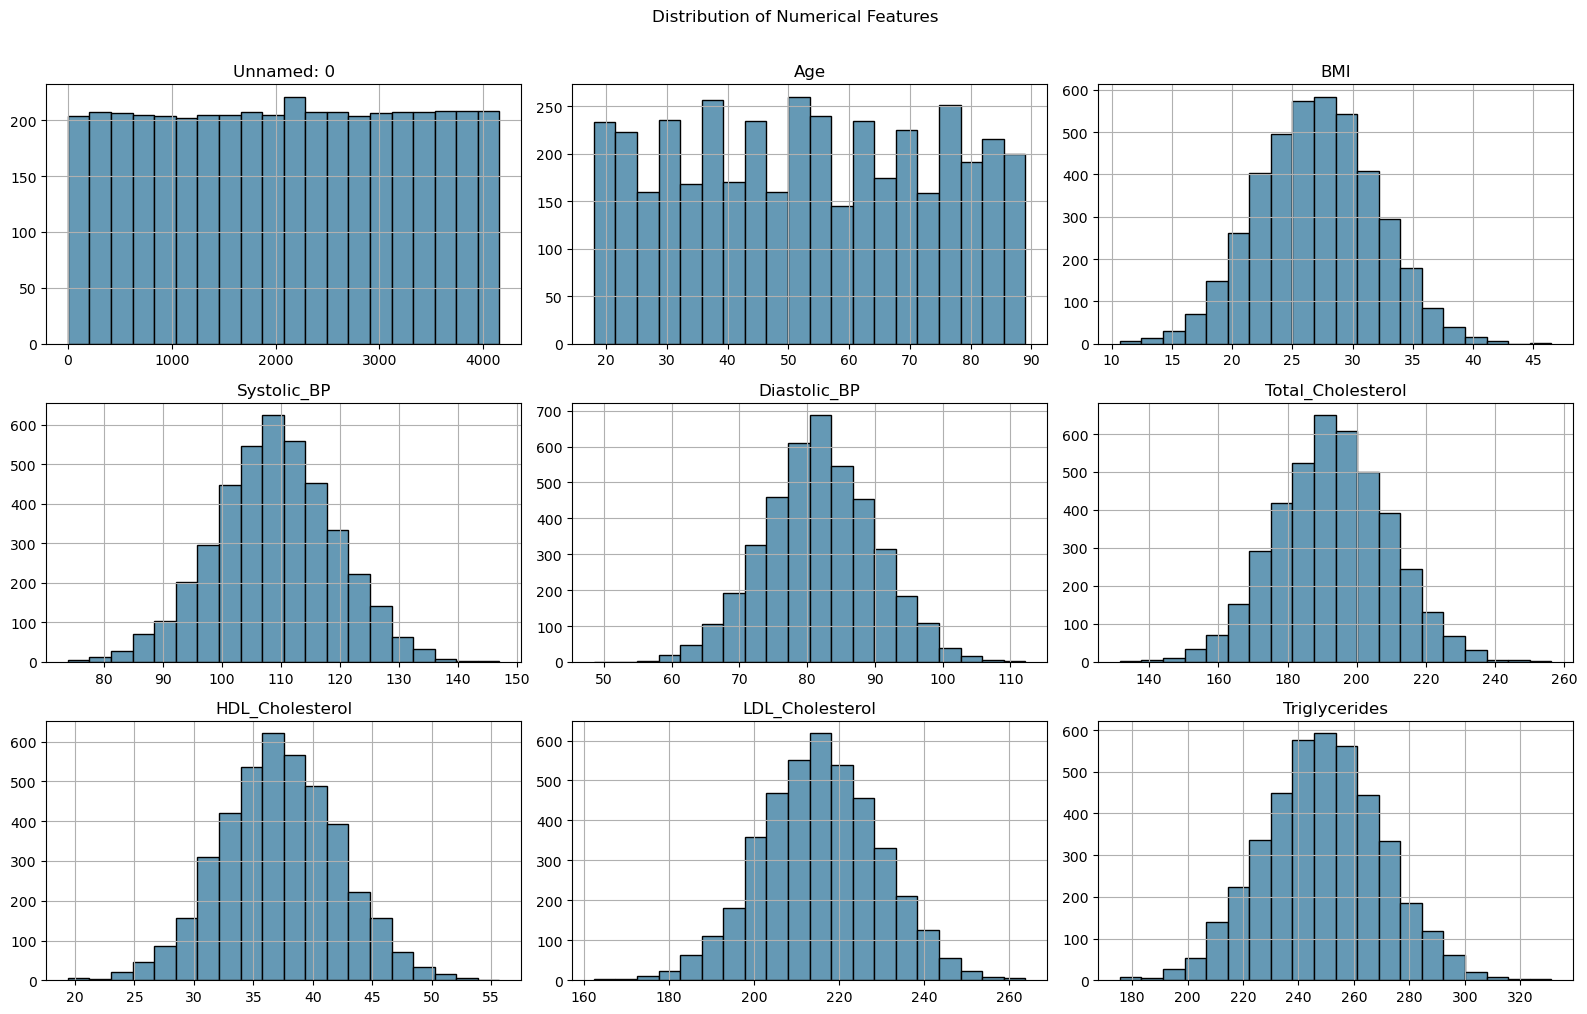

In [21]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black', color='#6599b5')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Most variables (such as BMI, Blood Pressure, and Cholesterol) have a shape close to a Normal Distribution (bell-shaped), which is a good indicator that the data is fairly balanced without strong bias.

### Physical Activity Level Proportions (Pie Chart)
We plot a pie chart to see how individuals are distributed across physical activity levels (low / moderate / high).

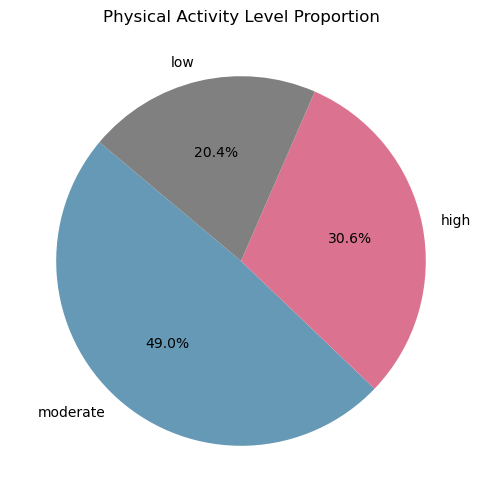

In [22]:
plt.figure(figsize=(8, 6))
activity_counts = df['Physical_Activity_Level'].value_counts()
plt.pie(activity_counts, labels=activity_counts.index, autopct='%.1f%%', startangle=140,colors = ['#6599b5', '#db7390','gray'])
plt.title('Physical Activity Level Proportion')
plt.show()

**Interpretation:** The chart shows the percentage of each `Physical_Activity_Level` category out of the total number of individuals, which helps us identify whether there is class imbalance in this variable or whether the categories are fairly balanced.

### Total Cholesterol Boxplot
A Boxplot shows the distribution of values and highlights outliers - values that lie far from the rest of the data.

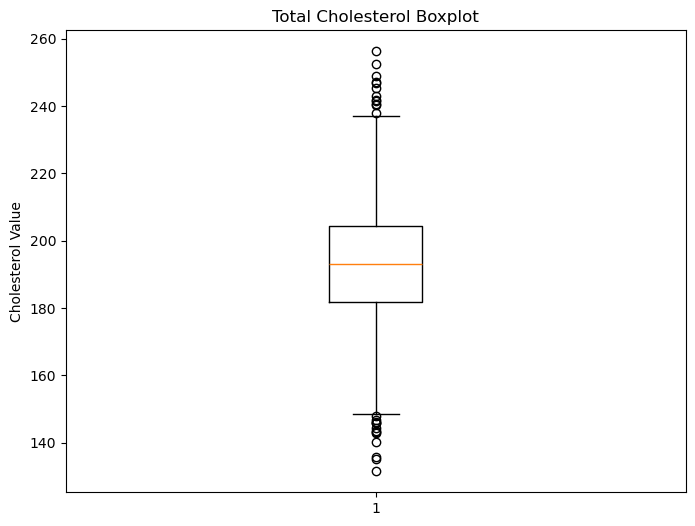

In [23]:
plt.figure(figsize=(8, 6))
plt.boxplot(df["Total_Cholesterol"].dropna())
plt.title('Total Cholesterol Boxplot')
plt.ylabel('Cholesterol Value')
plt.show()

**Interpretation:** The boxplot shows the interquartile range (IQR) of the `Total_Cholesterol` column, and any point outside the whiskers is a potential outlier, which we will address later using capping.

### Average Cholesterol by Smoking Status (Bar Chart)
We compare the average `Total_Cholesterol` between smokers and non-smokers.

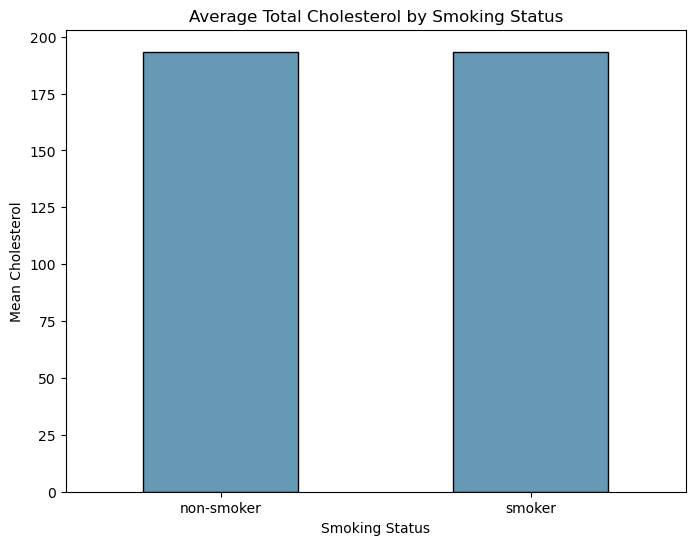

In [24]:
plt.figure(figsize=(8, 6))
df.groupby('Smoking_Status')['Total_Cholesterol'].mean().plot(kind='bar', color='#6599b5', edgecolor='black')
plt.title('Average Total Cholesterol by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Mean Cholesterol')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The chart shows whether there is a noticeable difference in average cholesterol between the `smoker` and `non-smoker` groups. If the difference is clear, it suggests that smoking may be associated with higher cholesterol levels in this dataset.

## 5. Data Preprocessing

In this stage, we prepare the data so it is clean and ready to be used in any Machine Learning model. This includes:
1. Dropping unnecessary columns.
2. Handling missing values.
3. Handling outliers.
4. Converting text data into numbers (Encoding).
5. Scaling the data to a common range (Scaling).

### Dropping Unnecessary Columns
The `Unnamed: 0` column is just a leftover index with no analytical value, so we drop it from the DataFrame.

In [25]:
cols_to_drop = ['Unnamed: 0']
df.drop(columns=cols_to_drop, inplace=True)
df.columns.tolist()

['Age',
 'BMI',
 'Systolic_BP',
 'Diastolic_BP',
 'Total_Cholesterol',
 'HDL_Cholesterol',
 'LDL_Cholesterol',
 'Triglycerides',
 'Smoking_Status',
 'Physical_Activity_Level']

**Interpretation:** The DataFrame now has 10 columns (`Unnamed: 0` has been removed), and this is what we will work with for the rest of the project.

### Handling Missing Values
- Numerical columns (float64/int64): missing values are filled with the column **mean**.
- Categorical columns (object): missing values are filled with the most frequent value in the column (**mode**).

In [26]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Age                        0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Total_Cholesterol          0
HDL_Cholesterol            0
LDL_Cholesterol            0
Triglycerides              0
Smoking_Status             0
Physical_Activity_Level    0
dtype: int64


**Interpretation:** After this step, every column has **zero** missing values, meaning the data is now complete with no missing values left.

### Outlier Detection and Capping
We use the **IQR (Interquartile Range)** method to detect outliers in each numerical column:
- Any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is considered an outlier.
- Instead of dropping these rows (which could lose a lot of data), we apply **capping**: replacing the outlier value with the nearest boundary (lower_bound or upper_bound).
- The code plots a boxplot before and after capping for each column so we can visually see the difference, and it prints the calculated boundary values below each plot.

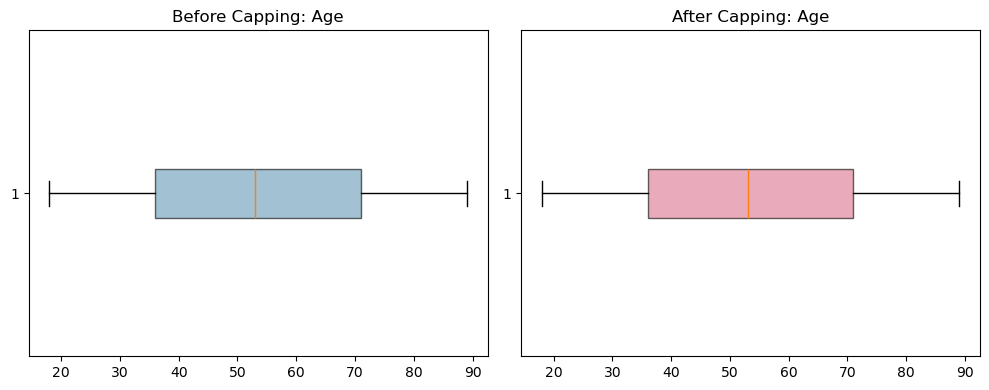

For 'Age': Outliers were detected and capped below -16.50 and above 123.50.
--------------------------------------------------------------------------------


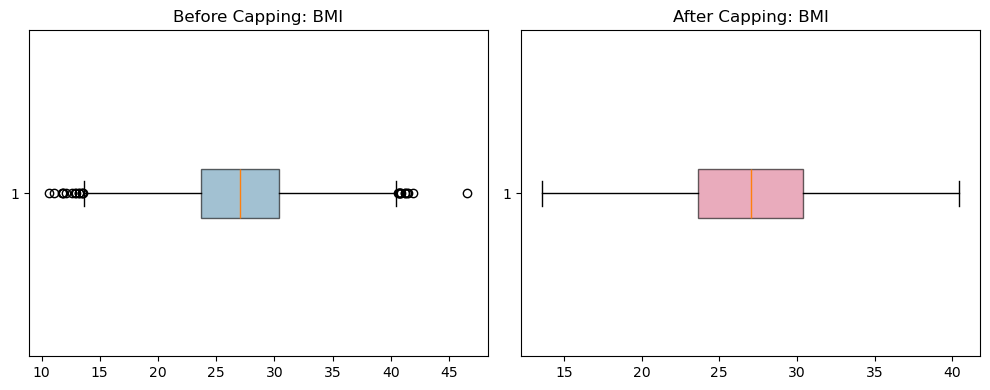

For 'BMI': Outliers were detected and capped below 13.58 and above 40.44.
--------------------------------------------------------------------------------


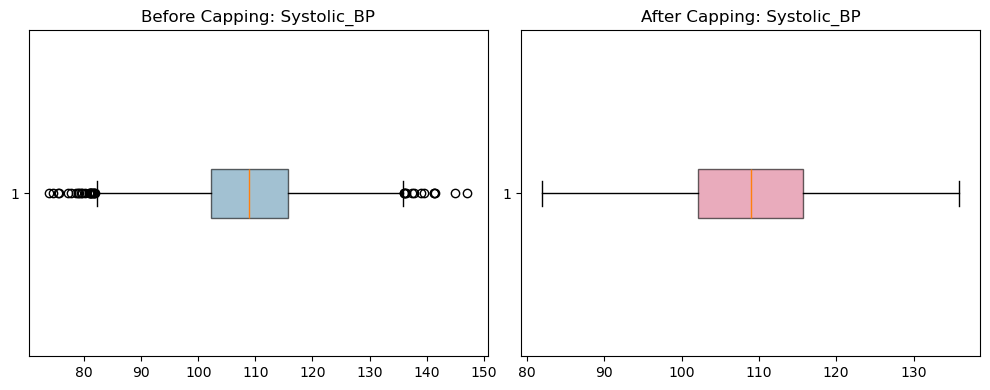

For 'Systolic_BP': Outliers were detected and capped below 81.95 and above 135.89.
--------------------------------------------------------------------------------


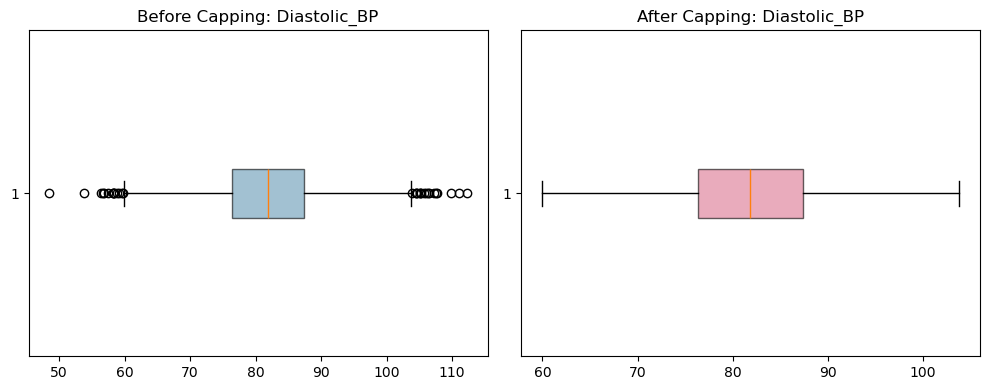

For 'Diastolic_BP': Outliers were detected and capped below 59.95 and above 103.80.
--------------------------------------------------------------------------------


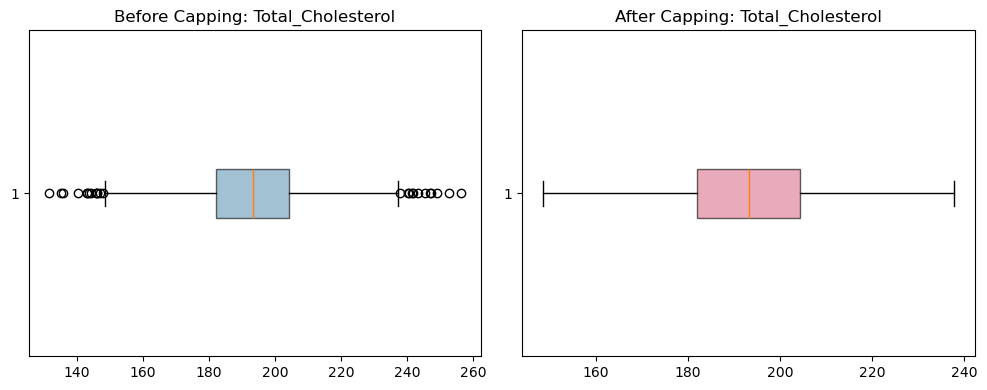

For 'Total_Cholesterol': Outliers were detected and capped below 148.42 and above 237.83.
--------------------------------------------------------------------------------


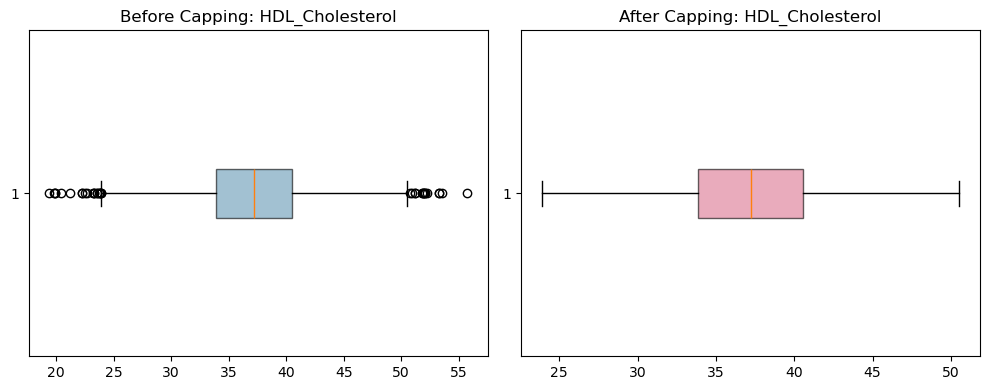

For 'HDL_Cholesterol': Outliers were detected and capped below 23.90 and above 50.52.
--------------------------------------------------------------------------------


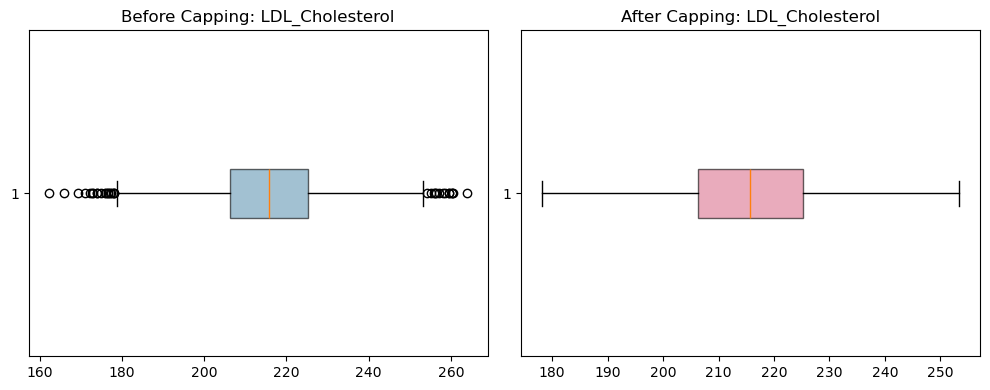

For 'LDL_Cholesterol': Outliers were detected and capped below 178.17 and above 253.39.
--------------------------------------------------------------------------------


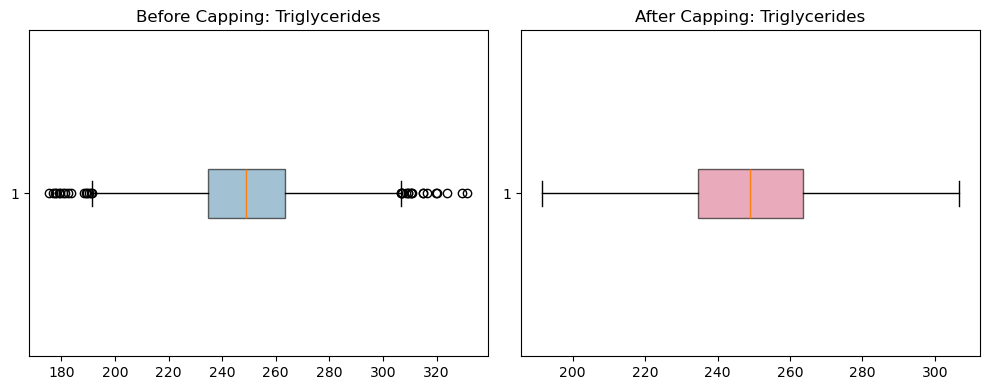

For 'Triglycerides': Outliers were detected and capped below 191.49 and above 306.71.
--------------------------------------------------------------------------------


In [28]:
current_num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['Unnamed: 0'], errors='ignore')

for col in current_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(10, 4))

    # Plot Before Capping
    plt.subplot(1, 2, 1)
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#6599b5', alpha=0.6))
    plt.title(f'Before Capping: {col}')

    # Applying Capping
    df[col] = np.where(df[col] > upper_bound, upper_bound,
              np.where(df[col] < lower_bound, lower_bound, df[col]))

    # Plot After Capping
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#db7390', alpha=0.6))
    plt.title(f'After Capping: {col}')

    plt.tight_layout()
    plt.show()

    # Print the exact boundary values below the plot
    print(f"For '{col}': Outliers were detected and capped below {lower_bound:.2f} and above {upper_bound:.2f}.")
    print("-" * 80)

**Interpretation:** Each column got a lower and upper bound, and any outlier beyond it was capped. For example:
- `Age`: between -16.50 and 123.50 (in practice almost no values are affected, since the natural age range already falls within these bounds).
- `BMI`: between 13.58 and 40.44.
- `Systolic_BP`: between 81.95 and 135.89.
- `Diastolic_BP`: between 59.95 and 103.80.
- `Total_Cholesterol`: between 148.42 and 237.83.
- `HDL_Cholesterol`: between 23.90 and 50.52.
- `LDL_Cholesterol`: between 178.17 and 253.39.
- `Triglycerides`: between 191.49 and 306.71.

The data is now cleaner and less affected by extreme values that could skew any model built on it later.

## 6. Encoding Categorical Data

Mathematical models (such as Machine Learning models) cannot work with text directly, so we need to convert text columns like `Smoking_Status` and `Physical_Activity_Level` into numbers. Here we use `LabelEncoder` from `sklearn`, which assigns a different number to each category.

> Note: we work on a new copy of the data called `df_final` to keep the original `df` unchanged.

In [29]:
from sklearn.preprocessing import LabelEncoder
df_final = df.copy()
le = LabelEncoder()
categorical_cols = df_final.select_dtypes(include='object').columns

for col in categorical_cols:
    df_final[col] = le.fit_transform(df_final[col])

df_final.head()

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,69.0,20.716059,107.148438,59.948303,168.918511,38.417674,183.835062,243.341527,0,2
1,32.0,26.720231,102.948326,86.641598,203.912014,39.611571,209.084595,266.375425,1,0
2,89.0,25.971636,116.327033,90.282522,213.564817,39.406223,245.884831,256.974525,0,2
3,78.0,29.580788,104.273800,85.582392,204.301914,33.026881,207.493647,257.717821,0,2
4,38.0,28.353130,104.052584,81.326270,195.767143,34.558842,213.826737,246.513400,0,2


**Interpretation:** The categorical columns have been converted into numbers. For example, `Smoking_Status`: (0 = non-smoker, 1 = smoker), and `Physical_Activity_Level`: each category (low/moderate/high) is now mapped to a corresponding number. The rest of the numerical columns remain unchanged.

## 7. Feature Scaling

Our numerical columns have very different scales (for example, Age ranges from 18 to 89, while Cholesterol ranges from 130 to 260). This can negatively affect many models that rely on distances (such as KNN, SVM, and Logistic Regression). So we use `StandardScaler`, which transforms each column to have a mean of 0 and a standard deviation of 1 (standardization).

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = df_final.select_dtypes(include=['float64', 'int32']).columns.drop(['Unnamed: 0'], errors='ignore')
df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

print(df_final.head())

        Age       BMI  Systolic_BP  Diastolic_BP  Total_Cholesterol  \
0  0.764993 -1.298967    -0.177381     -2.690134          -1.493364   
1 -1.037633 -0.063030    -0.587911      0.588175           0.660029   
2  1.739385 -0.217125     0.719758      1.035332           1.254033   
3  1.203469  0.525806    -0.458356      0.458090           0.684022   
4 -0.745315  0.273097    -0.479978     -0.064621           0.158818   

   HDL_Cholesterol  LDL_Cholesterol  Triglycerides  Smoking_Status  \
0         0.241383        -2.301996      -0.263291               0   
1         0.482583        -0.479809       0.816846               1   
2         0.441097         2.175958       0.376006               0   
3        -0.847706        -0.594624       0.410862               0   
4        -0.538208        -0.137583      -0.114551               0   

   Physical_Activity_Level  
0                        2  
1                        0  
2                        2  
3                        2  
4      

**Interpretation:** All values are now on roughly the same scale (generally between -3 and +3), so no single column will dominate the others due to differences in units or range. `df_final` is now fully ready to be used as input for any Machine Learning model.

---

## Project Summary
- Explored the data and understood its shape and distribution.
- Visualized the data to understand relationships between different variables.
- Handled missing values and outliers.
- Converted text data into numbers (Encoding) and standardized the numerical columns (Scaling).
- The final output, `df_final`, is a clean dataset ready for the next step, such as building a Machine Learning model.